In [4]:
# Import Libraries

import numpy as np
import pandas as pd

In [5]:
# Import Dataset
df=pd.read_csv("./sms.csv")

In [6]:
df.head()

,type,text
0,ham,Hope you are having a good week. Just checking in
1,ham,K..give back my thanks.
2,ham,Am also doing in cbe only. But have to pay.
3,spam,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,spam,okmail: Dear Dave this is your final notice to...


In [7]:
df=df.rename(columns={'type':'label','text':'message'})
df.head()

,label,message
0,ham,Hope you are having a good week. Just checking in
1,ham,K..give back my thanks.
2,ham,Am also doing in cbe only. But have to pay.
3,spam,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,spam,okmail: Dear Dave this is your final notice to...


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5559 entries, 0 to 5558
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5559 non-null   object
 1   message  5559 non-null   object
dtypes: object(2)
memory usage: 87.0+ KB


In [9]:
df.describe()

,label,message
count,5559,5559
unique,2,5156
top,ham,"Sorry, I'll call later"
freq,4812,30


In [10]:
df['label']=df['label'].map({'ham':0, 'spam':1})
df

,label,message
0,0,Hope you are having a good week. Just checking in
1,0,K..give back my thanks.
2,0,Am also doing in cbe only. But have to pay.
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,1,okmail: Dear Dave this is your final notice to...
...,...,...
5554,0,You are a great role model. You are giving so ...
5555,0,"Awesome, I remember the last time we got someb..."
5556,1,"If you don't, your prize will go to another cu..."
5557,1,"SMS. ac JSco: Energy is high, but u may not kn..."


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

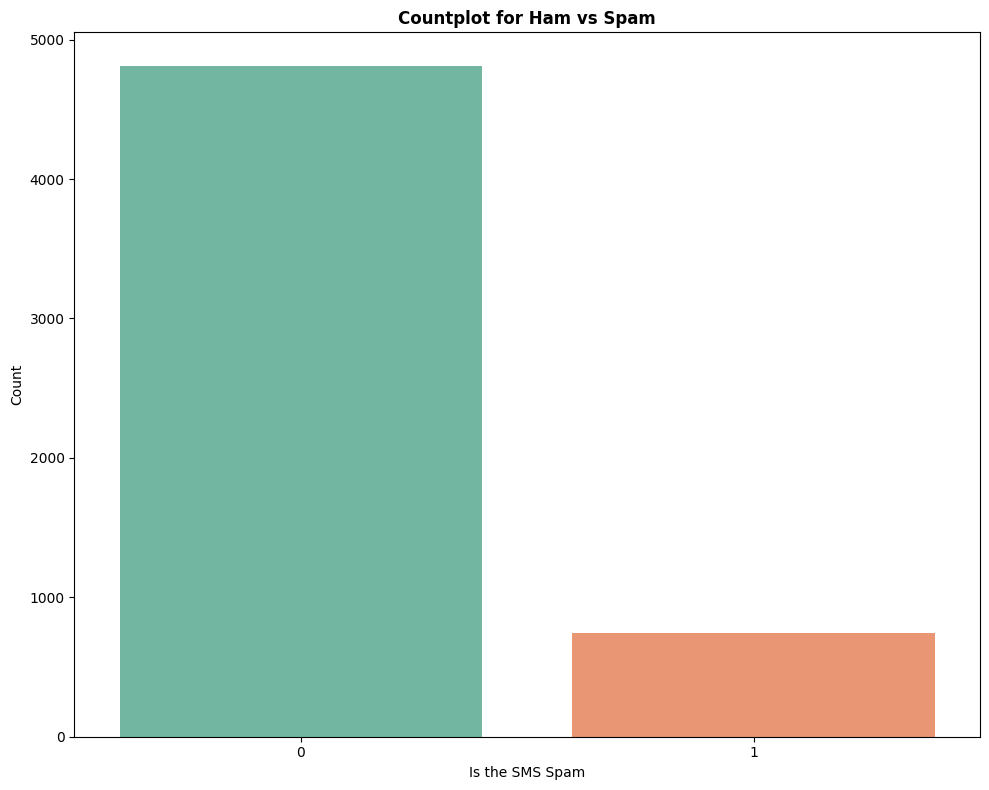

In [12]:
plt.figure(figsize=(10,8))
sns.countplot(df,x='label',palette="Set2")
plt.title('Countplot for Ham vs Spam',fontweight='bold',fontsize=12)
plt.xlabel('Is the SMS Spam')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [13]:
# From countplot we can see that our data is imbalanced so we have to balance it using Ovversampling
# Feature Engineering - Upsampling (Oversampling)

only_spam=df[df['label']==1]
only_spam


,label,message
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,1,okmail: Dear Dave this is your final notice to...
8,1,Marvel Mobile Play the official Ultimate Spide...
19,1,U can WIN £100 of Music Gift Vouchers every we...
34,1,U have won a nokia 6230 plus a free digital ca...
...,...,...
5532,1,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...
5538,1,HOT LIVE FANTASIES call now 08707509020 Just 2...
5551,1,Ur balance is now £500. Ur next question is: W...
5556,1,"If you don't, your prize will go to another cu..."


In [14]:
print('No of Spam SMS:', len(only_spam))
print('No of Ham SMS:', len(df)-len(only_spam))

No of Spam SMS: 747
No of Ham SMS: 4812


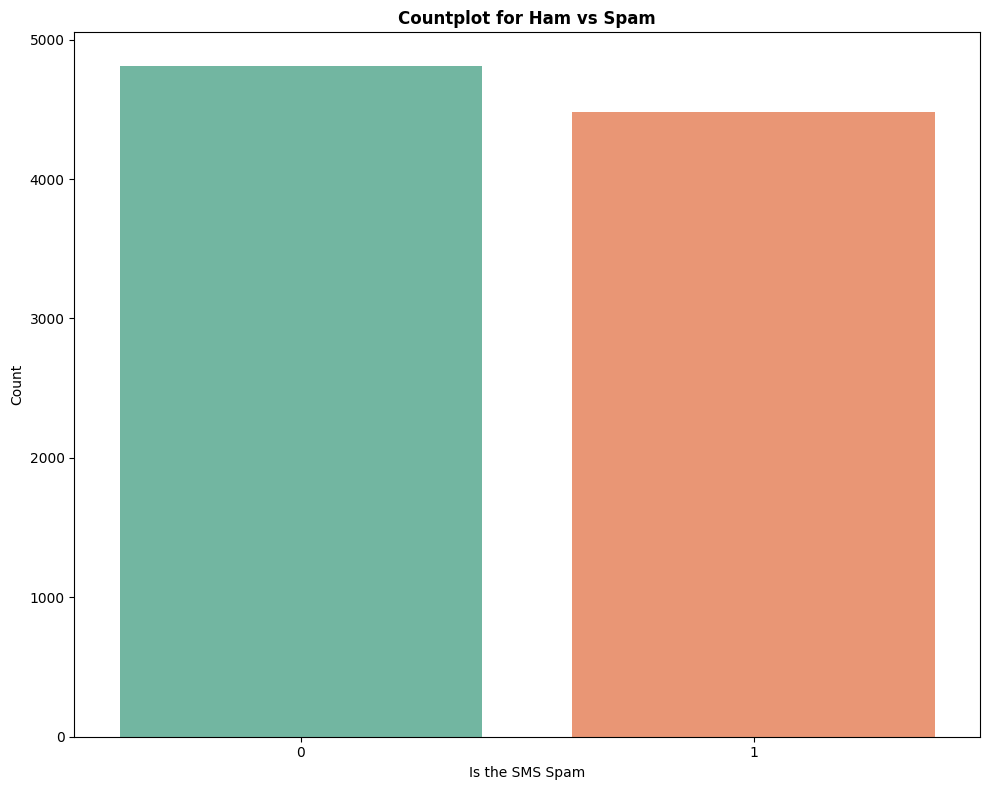

In [15]:
# 4825/747 = 6
count=int((df.shape[0] - only_spam.shape[0])/only_spam.shape[0])

for i in range(0,count-1):
    df=pd.concat([df,only_spam])

plt.figure(figsize=(10,8))
sns.countplot(df,x='label',palette="Set2")
plt.title('Countplot for Ham vs Spam',fontweight='bold',fontsize=12)
plt.xlabel('Is the SMS Spam')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

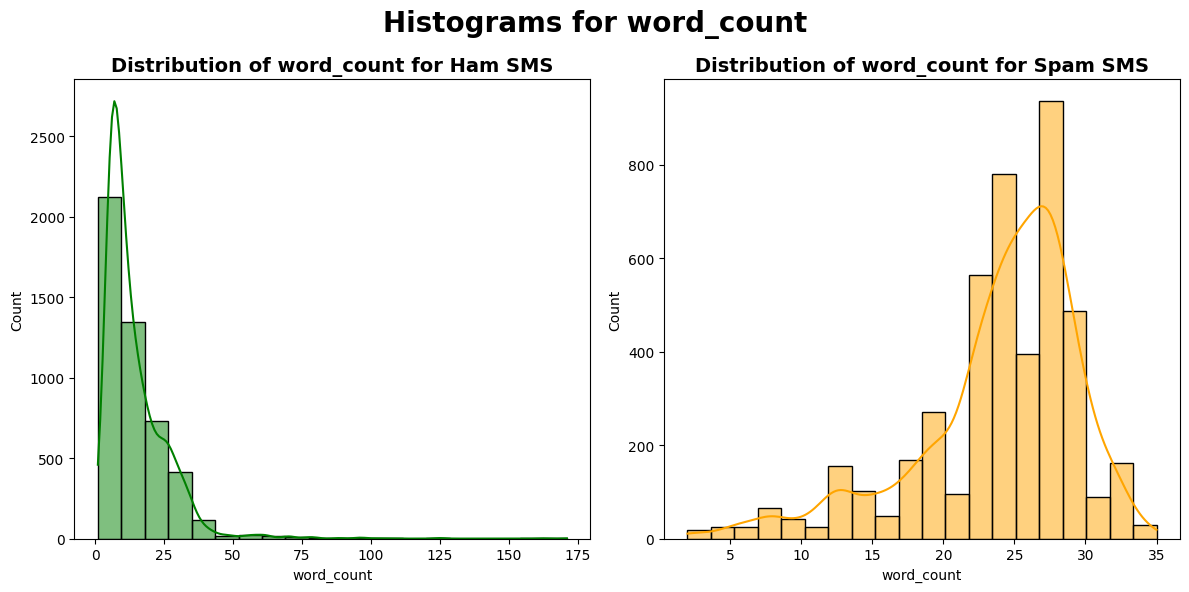

In [16]:
# Feature Engineering - Feature Extraction and Selection

# 1. Word Count

df['word_count']=df['message'].apply(lambda x:len(x.split()))

fig,axes=plt.subplots(1,2,figsize=(12,6))
axes=axes.flatten()
colors=['green','orange']
labels = ['Ham', 'Spam']

for i in range(2):
    data_subset = df[df['label'] == i]['word_count']
    sns.histplot(data_subset, bins=20, color=colors[i], ax=axes[i],kde=True)
    axes[i].set_title(f'Distribution of word_count for {labels[i]} SMS', 
                      fontweight='bold', fontsize=14)
    
plt.suptitle('Histograms for word_count',fontweight='bold',fontsize=20)
plt.tight_layout()
plt.show()

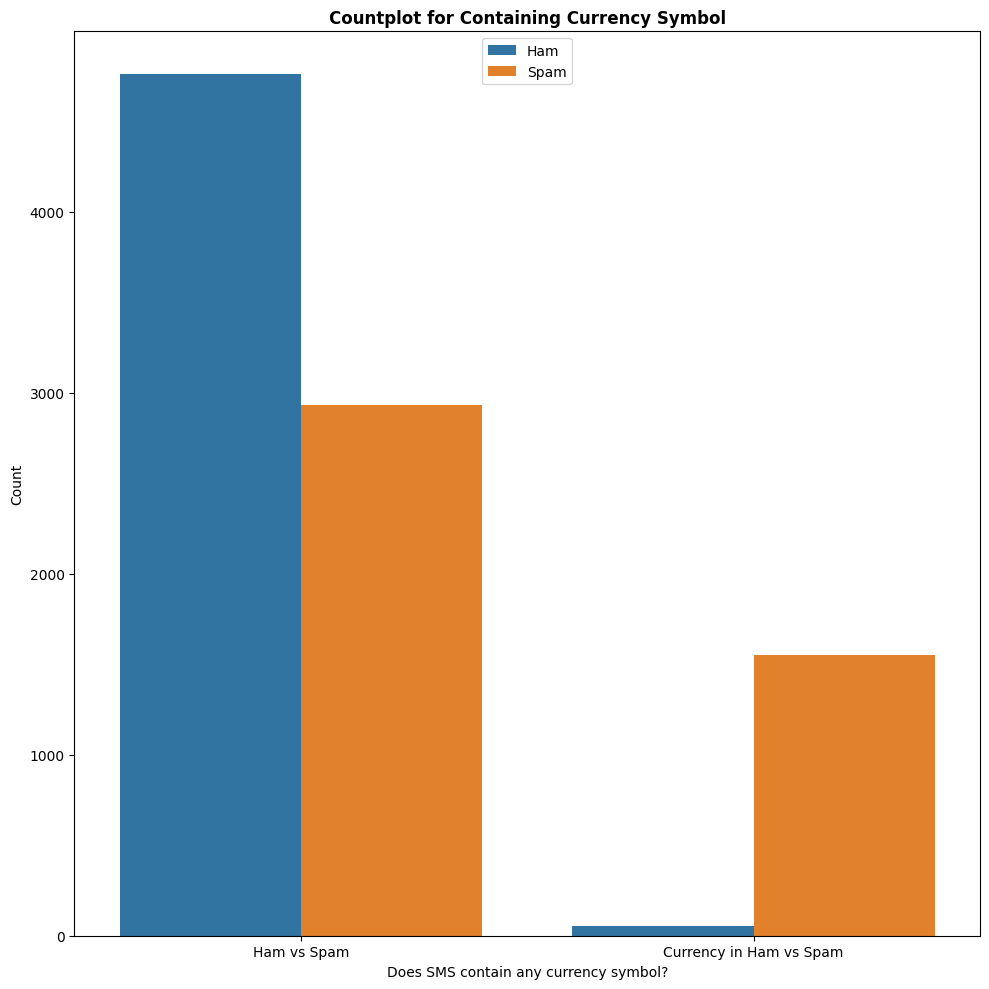

In [17]:
# 2. Contains Currency symbol or not

def currency_present(data):
    currency_symbol=['₹','$','€','¥','£']
    for cur in currency_symbol:
        if cur in data:
            return 1
    return 0

df["contains_currency_symbols"]=df["message"].apply(currency_present)

# Countplot for contain_currency_symbols

plt.figure(figsize=(10,10))
sns.countplot(df,x='contains_currency_symbols',hue="label")
plt.title('Countplot for Containing Currency Symbol',fontweight='bold',fontsize=12)
plt.xlabel('Does SMS contain any currency symbol?')
plt.xticks(ticks=[0, 1], labels=['Ham vs Spam', 'Currency in Ham vs Spam'])
plt.ylabel('Count')
plt.legend(labels=["Ham","Spam"],loc=9)
plt.tight_layout()
plt.show()

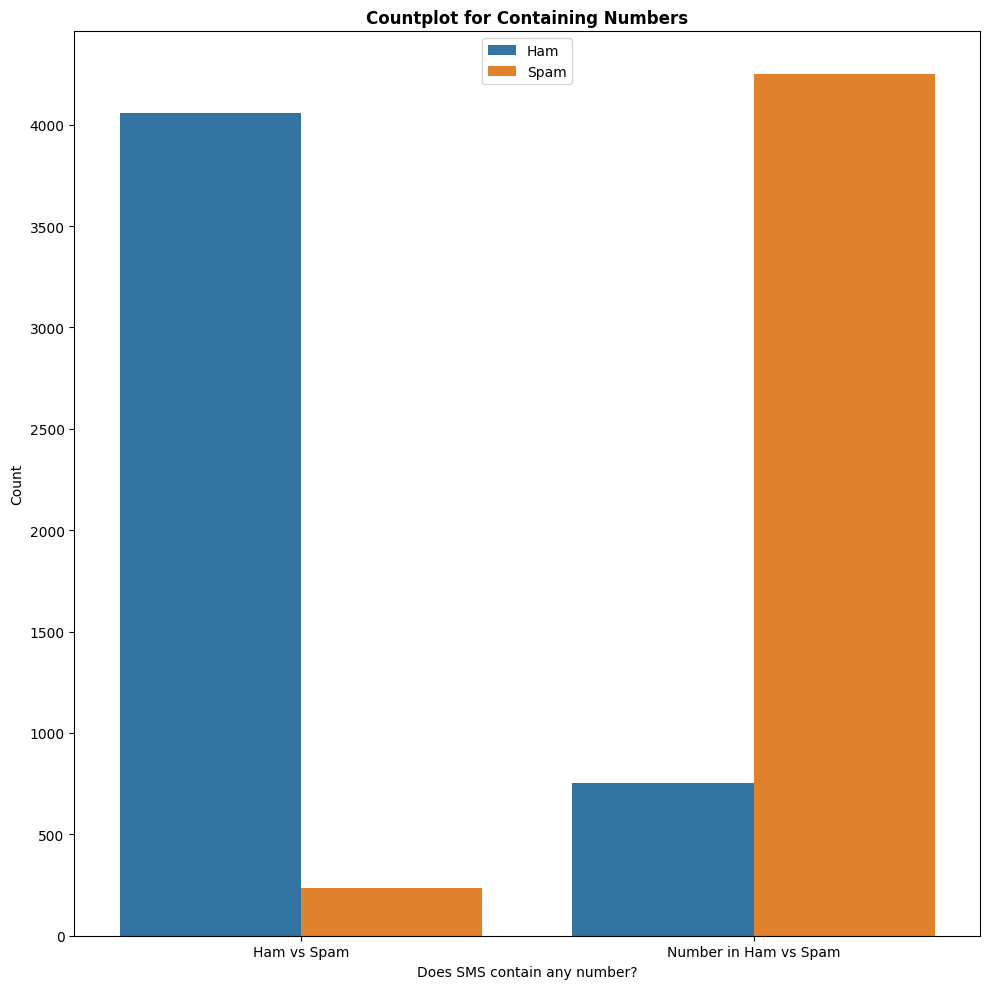

In [18]:
# 3.Containing Numbers or not

# We have to use ASCII value for detection as 'message' format is string

def contain_numbers(data):
    for num in data:
        if ord(num) >=48 and ord(num)<=57:
            return 1

    return 0

df["contains_number"]=df['message'].apply(contain_numbers)

# Countplot for contains_number

plt.figure(figsize=(10,10))
sns.countplot(df,x='contains_number',hue="label")
plt.title('Countplot for Containing Numbers',fontweight='bold',fontsize=12)
plt.xlabel('Does SMS contain any number?')
plt.xticks(ticks=[0, 1], labels=['Ham vs Spam', 'Number in Ham vs Spam'])
plt.ylabel('Count')
plt.legend(labels=["Ham","Spam"],loc=9)
plt.tight_layout()
plt.show()


In [19]:
# Data Cleaning

import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to C:\Users\jagneswar
[nltk_data]     panda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\jagneswar
[nltk_data]     panda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [20]:
corpus=[]
wnl=WordNetLemmatizer()

for sms in list(df.message):
    message=re.sub(pattern='[^a-zA-Z]' , repl=' ', string=sms) # Filtering for special characters and number
    message=message.lower()
    words=message.split() # Tokenizer
    filtered_words=[word for word in words if word not in set(stopwords.words('english'))]
    lemm_words=[wnl.lemmatize(word) for word in filtered_words]
    message=' '.join(lemm_words)

    corpus.append(message)

corpus

['hope good week checking',
 'k give back thanks',
 'also cbe pay',
 'complimentary star ibiza holiday cash need urgent collection landline lose box sk wp ppm',
 'okmail dear dave final notice collect tenerife holiday cash award call landline tc sae box cw wx ppm',
 'aiya discus later lar pick u',
 'much buzy',
 'please ask mummy call father',
 'marvel mobile play official ultimate spider man game ur mobile right text spider game send u free ball wallpaper',
 'fyi usf swing room whenever',
 'sure thing big man hockey election go longer hour though',
 'anything lor',
 'march ending ready call sure problem capital never complete far work lady',
 'hmm well night night',
 'k sure get noon see',
 'ha ha cool cool chikku chikku db',
 'darren saying dat u meeting da ge den dun meet dinner co later u leave xy feel awkward den u meet lunch lor',
 'dint tell anything angry told abi',
 'u u wan come come lor din c stripe skirt',
 'u win music gift voucher every week starting txt word draw tscs ww

In [21]:
# Creating the Bag of Words Model

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=500)
vectors=tfidf.fit_transform(corpus).toarray()
feature_names=tfidf.get_feature_names_out()

X=pd.DataFrame(vectors,columns=feature_names)
y=df['label']



In [22]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report,confusion_matrix

In [23]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train


,ac,access,account,address,admirer,age,already,also,always,an,...,xxx,ya,yeah,year,yes,yesterday,yet,yo,yr,yup
7484,0.0,0.0,0.429593,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5123,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2906,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3994,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.500852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.0,0.0,0.000000,0.0,0.0,0.297659,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5191,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
X_test

,ac,access,account,address,admirer,age,already,also,always,an,...,xxx,ya,yeah,year,yes,yesterday,yet,yo,yr,yup
5521,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1112,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
6395,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
4058,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
3733,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.375054,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
4467,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.443901,0.0,0.0,0.0
6850,0.0,0.0,0.303755,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
5441,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


In [26]:
# Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
mnb=MultinomialNB()

cv=cross_val_score(mnb,X,y,scoring='f1',cv=10)
print(round(cv.mean(),3))
print(round(cv.std(),3))

mnb.fit(X_train,y_train)
y_pred=mnb.predict(X_test)

print(classification_report(y_test,y_pred))


0.939
0.005
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       939
           1       0.95      0.93      0.94       920

    accuracy                           0.94      1859
   macro avg       0.94      0.94      0.94      1859
weighted avg       0.94      0.94      0.94      1859



In [27]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[891,  48],
       [ 61, 859]], dtype=int64)

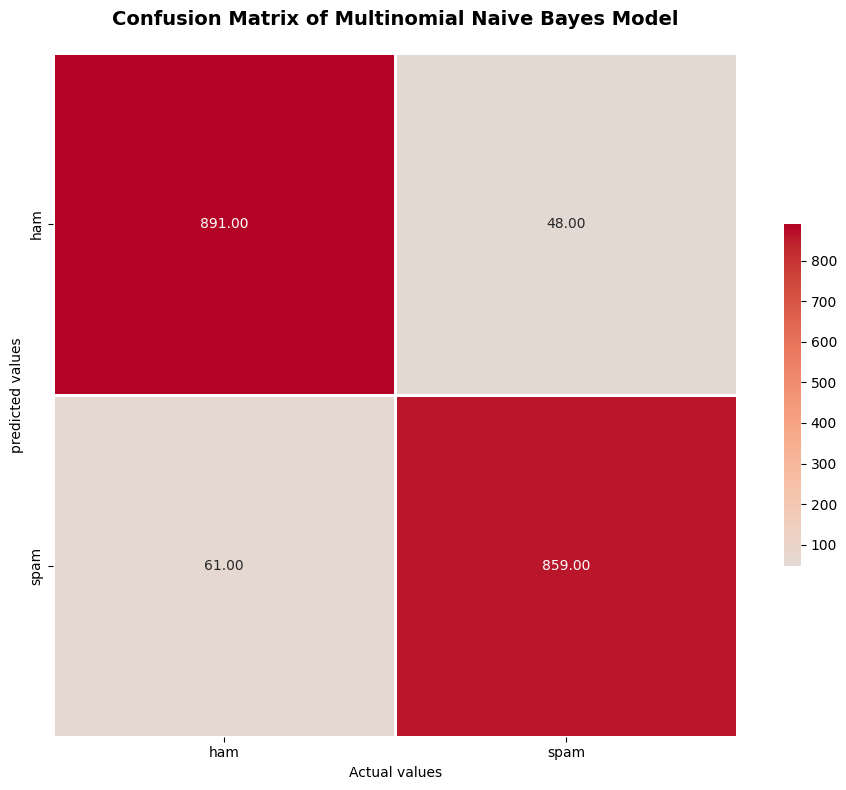

In [28]:
plt.figure(figsize=(10,8))
axis_labels=['ham','spam']

sns.heatmap(data=cm,xticklabels=axis_labels,yticklabels=axis_labels, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.5})

plt.title('Confusion Matrix of Multinomial Naive Bayes Model', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Actual values')
plt.ylabel('predicted values')
plt.tight_layout()
plt.show()



In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
# Applying random forest to avoid overfitting

rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning for improving accuracy and f1 score

param_grid = {
    'n_estimators': [50, 100, 200],     
    'max_depth': [None, 10, 20, 30],      
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [1, 2, 4]          
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=1, scoring='f1')

print("Tuning hyperparameters...")
grid_search.fit(X_train, y_train)

Tuning hyperparameters...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

In [31]:
best_rf = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [32]:
cv_rf = cross_val_score(best_rf, X, y, scoring='f1', cv=10)
print(f"Mean CV F1 Score: {round(cv_rf.mean(), 3)}")
print(f"Std CV F1 Score: {round(cv_rf.std(), 3)}")

Mean CV F1 Score: 0.995
Std CV F1 Score: 0.002


In [33]:
# Generate predictions on the test set
y_pred_rf = best_rf.predict(X_test)

In [34]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       939
           1       0.99      1.00      0.99       920

    accuracy                           0.99      1859
   macro avg       0.99      0.99      0.99      1859
weighted avg       0.99      0.99      0.99      1859



In [35]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[931   8]
 [  2 918]]


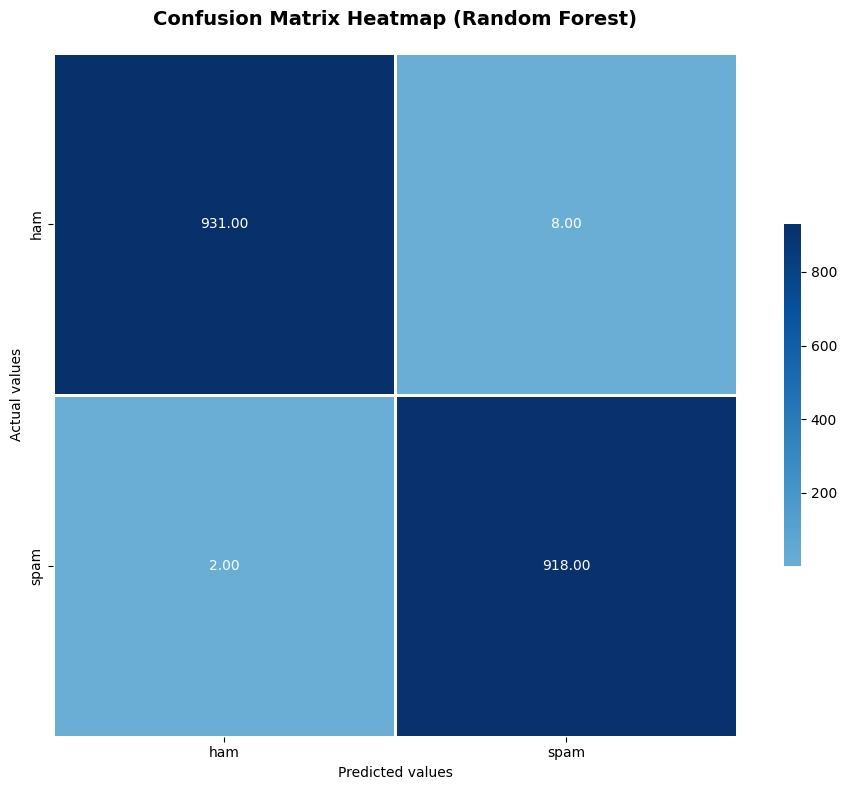

In [36]:
plt.figure(figsize=(10,8))
axis_labels=['ham','spam']

sns.heatmap(data=cm_rf,xticklabels=axis_labels,yticklabels=axis_labels, annot=True, fmt='.2f', cmap='Blues', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.5})

plt.title('Confusion Matrix Heatmap (Random Forest)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.tight_layout()
plt.show()


In [37]:
def predict_spam(sms,model):
    message=re.sub(pattern='[^a-zA-Z]' , repl=' ', string=sms) # Filtering for special characters and number
    message=message.lower()
    words=message.split() # Tokenizer
    filtered_words=[word for word in words if word not in set(stopwords.words('english'))]
    lemm_words=[wnl.lemmatize(word) for word in filtered_words]
    message=' '.join(lemm_words)
    temp=tfidf.transform([message]).toarray()
    return model.predict(temp)


In [38]:
# Prediction 1 - Lottery text message
sample_message = 'IMPORTANT - You could be entitled up to £3,160 in compensation from mis-sold PPI on a credit card or loan. Please reply PPI for info or STOP to opt out.'

if predict_spam(sample_message,best_rf):
  print('Gotcha! This is a SPAM message.')
else:
  print('This is a HAM (normal) message.')

Gotcha! This is a SPAM message.


In [39]:
# Prediction 2 - Casual text chat
sample_message = 'Came to think of it. I have never got a spam message before.'

if predict_spam(sample_message,best_rf):
  print('Gotcha! This is a SPAM message.')
else:
  print('This is a HAM (normal) message.')

This is a HAM (normal) message.


In [40]:
# Prediction 3 - Transaction confirmation text message
sample_message = 'Sam, your rent payment for Jan 19 has been received. $1,300 will be drafted from your wells Fargo Account ********234'

if predict_spam(sample_message,best_rf):
  print('Gotcha! This is a SPAM message.')
else:
  print('This is a HAM (normal) message.')

This is a HAM (normal) message.


In [41]:
import pickle

# Save the vectorizer
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))

# Save the best random forest model
pickle.dump(best_rf, open('model.pkl', 'wb'))

print("PKL files saved successfully!")

PKL files saved successfully!
